> **Chapter 13, Part 2** | Continues from [13.1 The Multi-Scale Pressure Field](13.1%20The%20Multi-Scale%20Pressure%20Field.ipynb). **Focus:** decoupling, but with a measurement procedure.

# Decoupling as Multi-Scale Decoherence

Meyer and Rowan (1977) introduced **decoupling** to describe the structural separation between formal organizational structure (policies, charts, public commitments) and operational practice (what people actually do). Decoupling is empirically pervasive: organizations adopt formal structures to gain legitimacy without necessarily implementing them, because implementation can be costly or impractical. The classical theory describes decoupling as a binary: either decoupled or not.

This notebook treats decoupling as a **scale-dependent divergence**. Decoupling at one scale (e.g., the firm publishes a model risk policy that contradicts how teams actually deploy models) is qualitatively different from decoupling at another (e.g., the field-level regulation contradicts the firm's internal rules). A scalar `decoupling_dimension` summarizes how decoupling propagates across scales. The math is intentionally simple. The conceptual yield is that decoupling stops being a yes/no judgment and becomes a measurement.

## Why this matters now

The Longpre et al. (2024) audit of 1,800 dataset cards found that 70% of dataset license categorizations on widely-used AI training corpora were wrong. Dataset cards are formal artifacts; their categorizations are operational claims. The 70% miscategorization rate is a decoupling measurement at the artifact scale. The same audit's finding that the miscategorization is uneven across hosts (Hugging Face, GitHub, etc.) is a multi-scale signal. Decoupling at the artifact scale propagates differently through different hosting ecosystems.

This notebook builds a `decoupling_dimension` measure on synthetic but plausible signals, then names what it would take to compute the same measure on real client data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

rng = np.random.default_rng(42)


def generate_signals(n_scales: int = 5, decoupling_at: dict = None, seed: int = 0):
    """Build synthetic formal/operational signal pairs across scales.

    `decoupling_at` is a dict {scale_index: divergence in [0, 1]} that injects
    scale-specific divergence between formal and operational at each level.
    """
    decoupling_at = decoupling_at or {}
    rng_local = np.random.default_rng(seed)
    formal = []
    operational = []
    for i in range(n_scales):
        base = rng_local.normal(loc=0.55, scale=0.05)
        formal.append(np.clip(base + rng_local.normal(0, 0.03, size=128), 0, 1))
        div = decoupling_at.get(i, 0.0)
        operational.append(np.clip(base - div + rng_local.normal(0, 0.04, size=128), 0, 1))
    return formal, operational


def decoupling_dimension(formal: Sequence[np.ndarray], operational: Sequence[np.ndarray]) -> float:
    """Return a scalar in [0, 1] summarizing scale-aggregated decoupling.

    Uses RMSE between formal and operational at each scale, then takes a
    weighted average favouring scales with more divergence (so that strong
    decoupling at any one scale is not washed out by quiet scales).
    """
    rmses = []
    for f_arr, o_arr in zip(formal, operational):
        rmses.append(float(np.sqrt(np.mean((f_arr - o_arr) ** 2))))
    arr = np.array(rmses)
    if arr.sum() == 0:
        return 0.0
    weights = arr / arr.sum()
    weighted = float(np.sum(arr * (1 + weights)))
    # Normalize so a single scale at maximum divergence (RMSE ~ 0.7) gives ~1.
    return float(min(weighted / 1.4, 1.0))


# Sanity check: aligned signals stay low; injected divergence pushes the dimension up.
f, o = generate_signals(decoupling_at={}, seed=1)
dd_aligned = decoupling_dimension(f, o)
f2, o2 = generate_signals(decoupling_at={1: 0.7}, seed=1)
dd_strong = decoupling_dimension(f2, o2)
assert dd_strong > dd_aligned + 0.1, f'expected strong decoupling > aligned + 0.1, got {dd_aligned:.3f} vs {dd_strong:.3f}'
print(f'Aligned signals decoupling dimension: {dd_aligned:.3f}')
print(f'One-scale strong decoupling dimension: {dd_strong:.3f}')


Aligned signals decoupling dimension: 0.216
One-scale strong decoupling dimension: 0.840


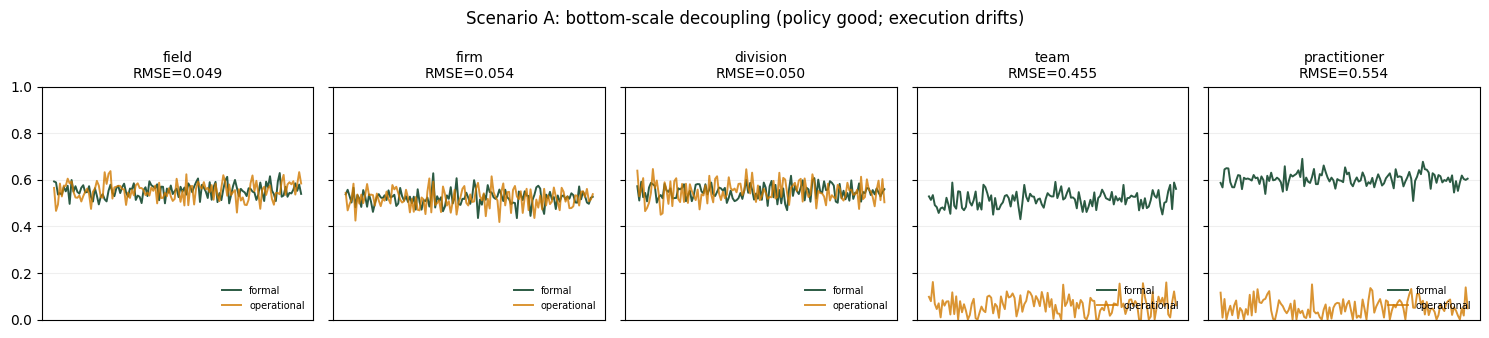

Decoupling dimension (Scenario A): 1.000



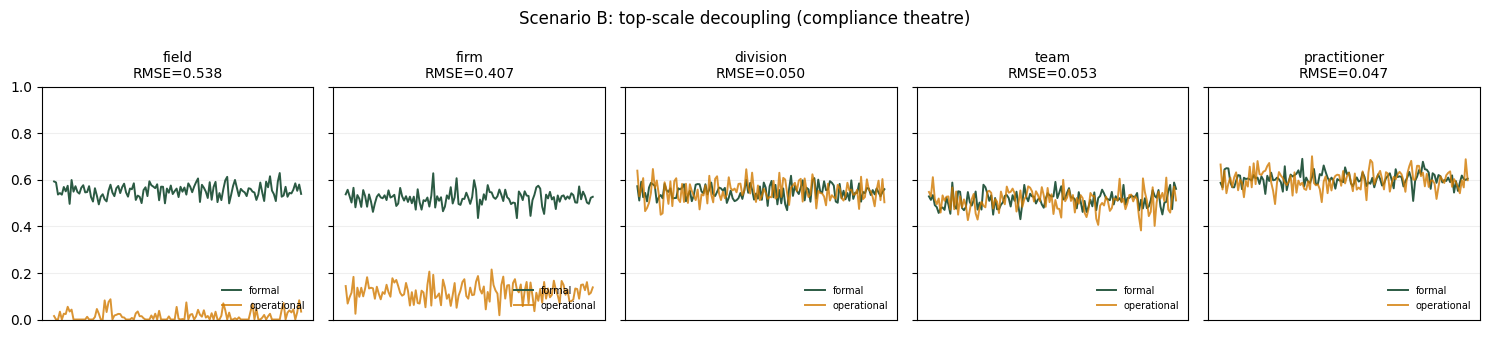

Decoupling dimension (Scenario B): 1.000



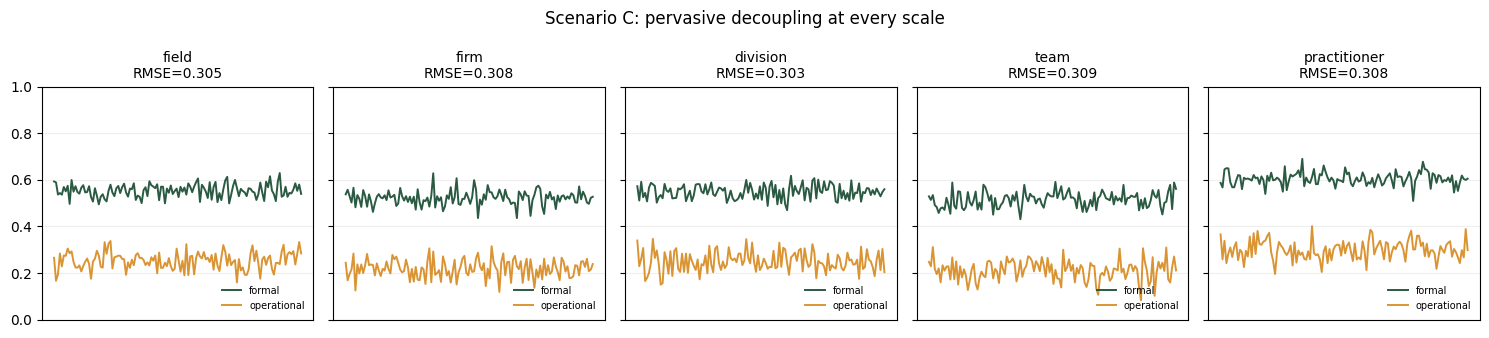

Decoupling dimension (Scenario C): 1.000


In [2]:
def render_decoupling(formal, operational, scale_labels, title=''):
    n = len(formal)
    fig, axes = plt.subplots(1, n, figsize=(15, 3.4), sharey=True)
    if n == 1:
        axes = [axes]
    rmses = []
    for ax, f_arr, o_arr, label in zip(axes, formal, operational, scale_labels):
        ax.plot(f_arr, label='formal', color='#2b5a43', linewidth=1.4)
        ax.plot(o_arr, label='operational', color='#d17a00', linewidth=1.4, alpha=0.8)
        rmse = float(np.sqrt(np.mean((f_arr - o_arr) ** 2)))
        rmses.append(rmse)
        ax.set_title(f'{label}\nRMSE={rmse:.3f}', fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.grid(alpha=0.2)
        ax.legend(loc='lower right', fontsize=7, frameon=False)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    return rmses


# Scenario A: governance lives at the level of policy. The firm-scale policy is loud
# but practitioners diverge. Decoupling concentrated at scales 3-4 (team, practitioner).
SCALE_LABELS = ['field', 'firm', 'division', 'team', 'practitioner']

f_A, o_A = generate_signals(decoupling_at={3: 0.45, 4: 0.55}, seed=11)
rmse_A = render_decoupling(f_A, o_A, SCALE_LABELS,
                           title='Scenario A: bottom-scale decoupling (policy good; execution drifts)')
dd_A = decoupling_dimension(f_A, o_A)
print(f'Decoupling dimension (Scenario A): {dd_A:.3f}\n')

# Scenario B: theatre at the top. Field-scale regulation says one thing; firm-scale
# claims compliance but the operational signal at field/firm is divergent.
f_B, o_B = generate_signals(decoupling_at={0: 0.55, 1: 0.40}, seed=11)
rmse_B = render_decoupling(f_B, o_B, SCALE_LABELS,
                           title='Scenario B: top-scale decoupling (compliance theatre)')
dd_B = decoupling_dimension(f_B, o_B)
print(f'Decoupling dimension (Scenario B): {dd_B:.3f}\n')

# Scenario C: continuous decoupling across all scales (rare in practice, but
# the worst-case shape). Real organizations usually concentrate decoupling somewhere.
f_C, o_C = generate_signals(decoupling_at={i: 0.30 for i in range(5)}, seed=11)
rmse_C = render_decoupling(f_C, o_C, SCALE_LABELS,
                           title='Scenario C: pervasive decoupling at every scale')
dd_C = decoupling_dimension(f_C, o_C)
print(f'Decoupling dimension (Scenario C): {dd_C:.3f}')


## Reading the three scenarios

- **Scenario A (bottom-scale decoupling).** Policy looks fine at the field and firm scales. The divergence concentrates at team and practitioner scales. This is the "policy good, execution drifts" pattern Walsh et al. (2025) describe in consulting firms. The decoupling dimension is moderate but the diagnostic is sharp because the structure says where the gap is.
- **Scenario B (top-scale decoupling).** Field-scale regulation is loud; firm-scale claims compliance; operational reality at the top scales diverges. This is **compliance theatre** in the classical Meyer-Rowan sense. The decoupling dimension can register as smaller than Scenario A even though the consequence (audit finding, regulatory penalty) is bigger.
- **Scenario C (pervasive decoupling).** Every scale shows divergence. Rare in practice; the dimension is high but the structure-free signal makes it harder to act on.

## What the dimension does and does not say

The `decoupling_dimension` is a scalar summary. It tells the reader "how much" but not "where." Reading the per-scale RMSE alongside the dimension is essential. This pattern repeats in Chapter 12: a single fractal dimension `d_B` is a useful triage number, but never a substitute for the box-cover plot it summarizes.

The single most important honesty note: this measurement requires both formal and operational signals to exist as time series or vectors. In real organizations, **the operational signal is exactly what's hard to obtain**. Interview transcripts give qualitative operational evidence; lineage manifests give partial structural evidence; incident logs give partial outcome evidence. The dissertation case study is one path to the operational signal. Notebook 13.5 introduces an AI-mediated path. Notebook 13.8 names where each path fails.


In [3]:
# Connecting back to Chapter 11.4: the duplicate-cluster threshold is itself a
# decoupling event. The match score (formal) and the steward judgment (operational)
# diverge at certain thresholds. The duplicate-cluster work is decoupling at one scale.
# Chapter 13's apparatus generalizes the same idea across many scales.
print('Connections to earlier chapters:')
print('- Ch 11.4: duplicate-cluster decoupling at a single scale (entity-resolution threshold)')
print('- Ch 12.5: lineage fault propagation as a structural blast-radius signal')
print('- Ch 12.6: entity resolution revisited as a graph; instability scores quantify match-score / steward-judgment decoupling')
print('- Ch 13.5 (next door): AI-mediated parsing turns interview text into operational signal vectors')
print()
print('The empirical roadmap is in non-git-files/governance-ai-fractals-research-plan.md.')


Connections to earlier chapters:
- Ch 11.4: duplicate-cluster decoupling at a single scale (entity-resolution threshold)
- Ch 12.5: lineage fault propagation as a structural blast-radius signal
- Ch 12.6: entity resolution revisited as a graph; instability scores quantify match-score / steward-judgment decoupling
- Ch 13.5 (next door): AI-mediated parsing turns interview text into operational signal vectors

The empirical roadmap is in non-git-files/governance-ai-fractals-research-plan.md.


## Practical implications

- **For practitioners:** when an audit finds something, ask not only "did we comply?" but "which scale was decoupled?" The locus matters more than the score for remediation planning.
- **For researchers:** the per-scale RMSE is the empirical handle. A reproducibility paper testing whether interview-derived RMSEs match instrumented-system RMSEs would be a strong contribution to the methods literature.
- **For students:** the apparatus is conceptually one line: subtract two signals at each scale and weight the result. The conceptual content is in deciding what the formal and operational signals are. The measurement is the easy part.

## How I would debug this

If `decoupling_dimension` returns near 0 in your environment, suspect that the formal and operational signals are coming from the same source. Independent measurement is the prerequisite for measuring divergence. Reading the dissertation interview protocol (Chen and Filieri, 2024 provides a template) is one way to ensure independence.
